
### Langkah 1: Memuat Dataset
Pada langkah pertama, kita akan memuat dataset dummy yang berisi informasi stok produk, volume penjualan, perkiraan permintaan, dan tingkat restok. Dataset ini akan digunakan untuk mengembangkan model pengelolaan inventori yang dapat membantu UMKM dalam memprediksi dan mengatur stok secara efisien.


In [1]:
import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('15_pengelolaan_inventori.xlsx')
dummy_df

,Product ID,Product Name,Stock Available,Sales Volume,Demand Forecast,Restock Level
0,1,Product D,145,145,51,106
1,2,Product E,284,141,198,80
2,3,Product C,185,46,144,183
3,4,Product E,99,35,185,147
4,5,Product E,134,134,116,61
...,...,...,...,...,...,...
295,296,Product E,40,40,106,53
296,297,Product E,224,72,136,148
297,298,Product C,45,39,125,190
298,299,Product D,232,104,105,88



### Langkah 2: Visualisasi Data
Pada langkah kedua, kita akan memvisualisasikan beberapa data terkait stok produk dan permintaan pasar. Kita akan melihat distribusi stok produk yang tersedia dan hubungan antara permintaan yang diperkirakan dan volume penjualan. Visualisasi ini membantu kita memahami pola dan distribusi stok serta permintaan yang ada.


<ipython-input-3-292be8ae57e0>:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Product Name', y='Stock Available', data=dummy_df, ci=None)  # ci=None removes error bars


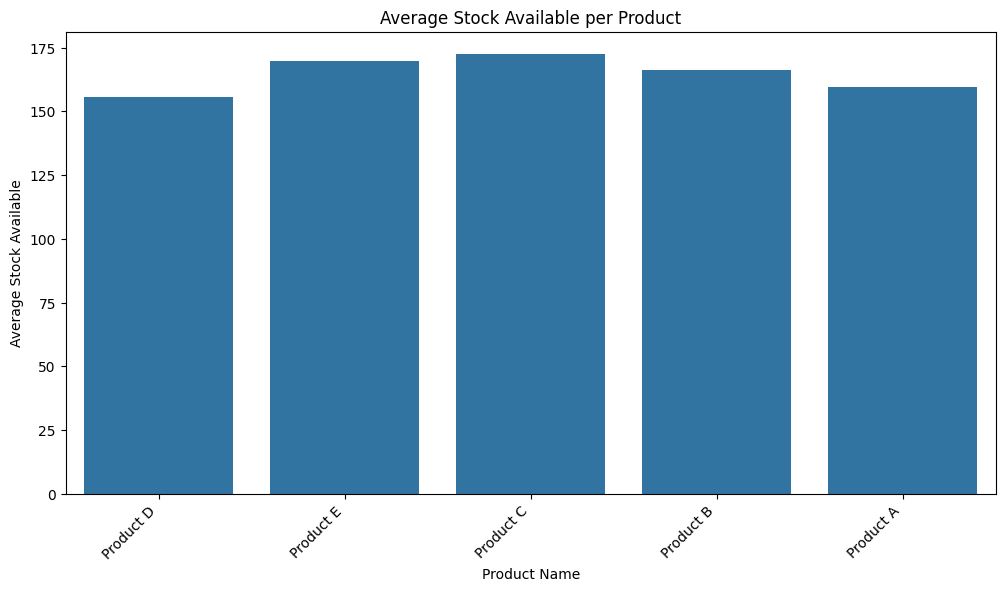

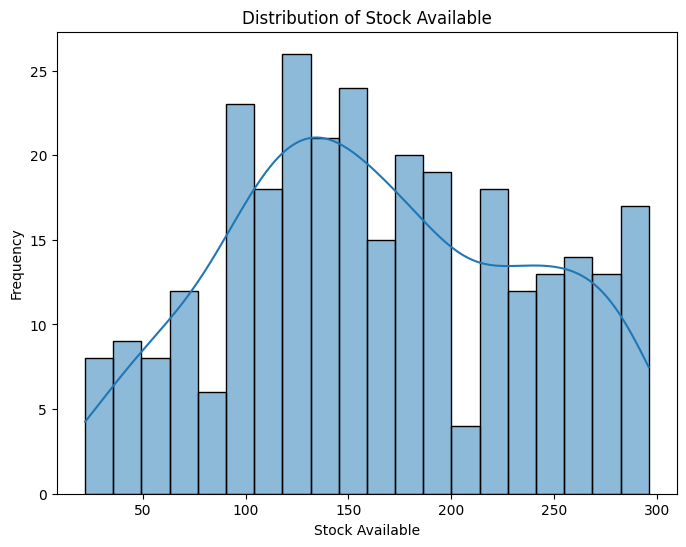

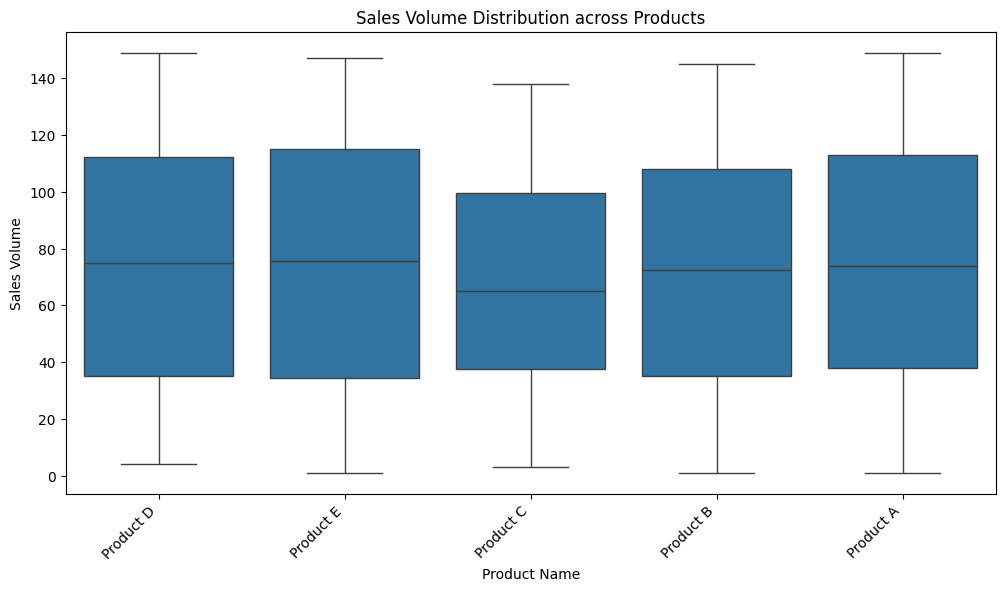

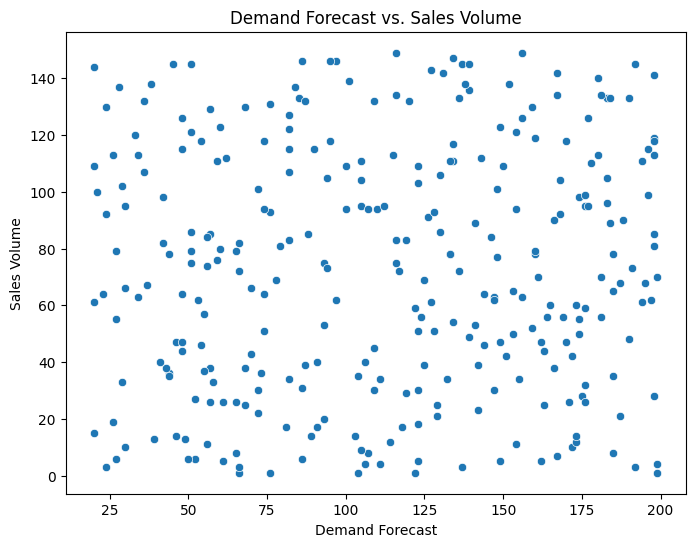

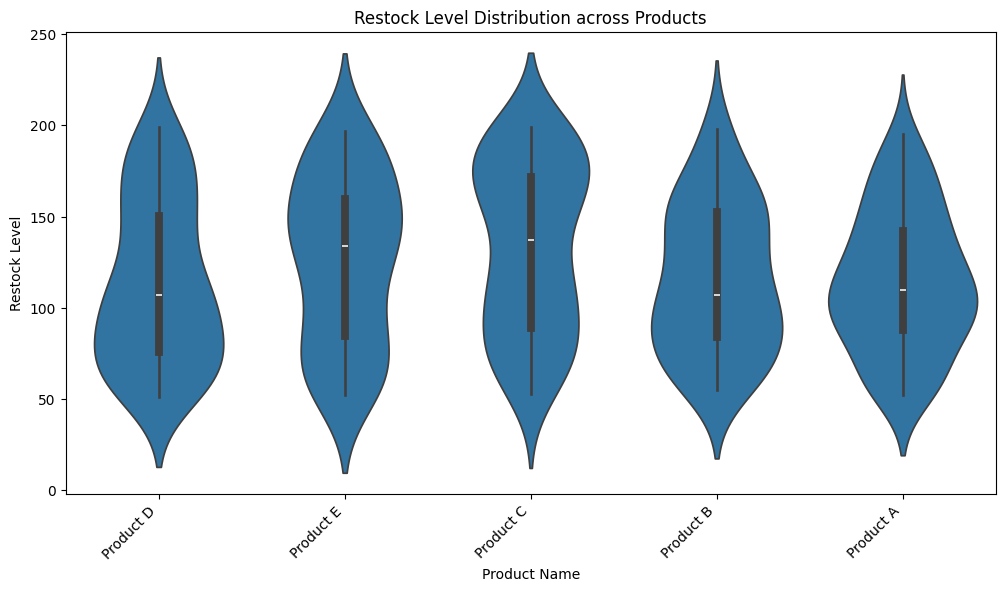

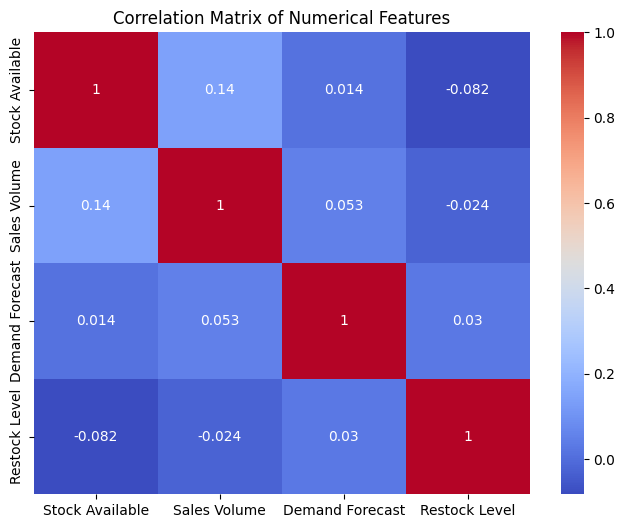

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'dummy_df' is your DataFrame

# 1. Product Name: Categorical - Bar Chart of Average Stock Available per Product
plt.figure(figsize=(12, 6))
sns.barplot(x='Product Name', y='Stock Available', data=dummy_df, ci=None)  # ci=None removes error bars
plt.title('Average Stock Available per Product')
plt.xlabel('Product Name')
plt.ylabel('Average Stock Available')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

# 2. Stock Available: Numerical - Histogram with KDE
plt.figure(figsize=(8, 6))
sns.histplot(dummy_df['Stock Available'], bins=20, kde=True)
plt.title('Distribution of Stock Available')
plt.xlabel('Stock Available')
plt.ylabel('Frequency')
plt.show()

# 3. Sales Volume: Numerical - Box Plot across Different Products
plt.figure(figsize=(12, 6))
sns.boxplot(x='Product Name', y='Sales Volume', data=dummy_df)
plt.title('Sales Volume Distribution across Products')
plt.xlabel('Product Name')
plt.ylabel('Sales Volume')
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Demand Forecast: Numerical - Scatter Plot against Sales Volume
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Demand Forecast', y='Sales Volume', data=dummy_df)
plt.title('Demand Forecast vs. Sales Volume')
plt.xlabel('Demand Forecast')
plt.ylabel('Sales Volume')
plt.show()

# 5. Restock Level: Numerical - Violin Plot across Different Products
plt.figure(figsize=(12, 6))
sns.violinplot(x='Product Name', y='Restock Level', data=dummy_df)
plt.title('Restock Level Distribution across Products')
plt.xlabel('Product Name')
plt.ylabel('Restock Level')
plt.xticks(rotation=45, ha='right')
plt.show()

# Optional: Correlation Heatmap for Numerical Features
numerical_features = ['Stock Available', 'Sales Volume', 'Demand Forecast', 'Restock Level']
correlation_matrix = dummy_df[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### Langkah 3: Preprocessing Data
Pada langkah ini, kita akan melakukan normalisasi pada data numerik seperti stok produk, volume penjualan, dan perkiraan permintaan agar berada pada skala yang sama. Normalisasi ini meningkatkan kinerja model pembelajaran mesin yang akan digunakan untuk memprediksi jumlah stok yang ideal.


In [4]:

# Langkah 3: Preprocessing Data
from sklearn.preprocessing import StandardScaler

# Melakukan normalisasi pada kolom stok, penjualan, dan perkiraan permintaan
scaler = StandardScaler()
dummy_df[['Stock Available', 'Sales Volume', 'Demand Forecast']] = scaler.fit_transform(dummy_df[['Stock Available', 'Sales Volume', 'Demand Forecast']])

# Memeriksa data setelah preprocessing
dummy_df.head()


,Product ID,Product Name,Stock Available,Sales Volume,Demand Forecast,Restock Level
0,1,Product D,-0.263507,1.690773,-1.168698,106
1,2,Product E,1.674115,1.597660,1.616172,80
2,3,Product C,0.294082,-0.613769,0.593158,183
3,4,Product E,-0.904735,-0.869829,1.369891,147
4,5,Product E,-0.416844,1.434713,0.062707,61



### Langkah 4: Normalisasi Data
Pada langkah ini, data sudah dinormalisasi pada langkah sebelumnya, sehingga kita tidak perlu melakukan normalisasi tambahan. Data yang sudah terstandarisasi memastikan bahwa semua fitur memiliki kontribusi yang setara dalam model yang akan dilatih.


In [5]:

# Langkah 4: Normalisasi Data
# Kolom-kolom yang sudah dinormalisasi dihasilkan pada langkah 3, jadi tidak perlu tindakan tambahan pada normalisasi
dummy_df.head()


,Product ID,Product Name,Stock Available,Sales Volume,Demand Forecast,Restock Level
0,1,Product D,-0.263507,1.690773,-1.168698,106
1,2,Product E,1.674115,1.597660,1.616172,80
2,3,Product C,0.294082,-0.613769,0.593158,183
3,4,Product E,-0.904735,-0.869829,1.369891,147
4,5,Product E,-0.416844,1.434713,0.062707,61



### Langkah 5: Membagi Data Train dan Test
Pada langkah ini, kita akan membagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi 80% untuk latih dan 20% untuk uji. Pembagian ini memungkinkan kita untuk melatih model pada data latih dan mengujinya dengan data uji yang belum pernah dilihat sebelumnya.


In [6]:

# Langkah 5: Membagi Data Train dan Test
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi fitur (X) dan target (y)
X = dummy_df[['Stock Available', 'Sales Volume', 'Demand Forecast']]
y = dummy_df['Restock Level']

# Membagi data menjadi data latih (train) dan data uji (test) dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran data train dan test
(X_train.shape, X_test.shape)


((240, 3), (60, 3))


### Langkah 6: Melatih Model
Pada langkah ini, kita akan menggunakan algoritma RandomForestRegressor untuk melatih model prediksi pengelolaan inventori. Regresi digunakan karena kita memprediksi nilai kontinu yaitu jumlah stok yang ideal. Model ini juga dapat membantu kita mengetahui fitur mana yang paling berpengaruh dalam menentukan tingkat restok produk.


In [7]:

# Langkah 6: Melatih Model
from sklearn.ensemble import RandomForestRegressor

# Membuat dan melatih model RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Melihat fitur penting dari model
model.feature_importances_


array([0.35801432, 0.29236634, 0.34961934])


### Langkah 7: Evaluasi Model
Pada langkah ini, kita akan mengevaluasi kinerja model dengan menggunakan data uji. Kita akan menghitung metrik evaluasi seperti Mean Absolute Error (MAE), Mean Squared Error (MSE), dan R-squared (R²) untuk menilai seberapa baik model memprediksi jumlah stok yang ideal.


In [12]:

# Langkah 7: Evaluasi Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Memprediksi harga pada data uji
y_pred = model.predict(X_test)

# Menghitung error dan menampilkan laporan evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2


(38.497666666666674, 2146.2585266666665, -0.4595543991416309)


### Langkah 8: Prediksi
Pada langkah terakhir, kita akan menggunakan model yang telah dilatih untuk memprediksi tingkat restok ideal berdasarkan data baru. Hal ini memungkinkan pengelolaan inventori yang lebih efisien dan responsif terhadap permintaan pasar.


In [11]:
# Langkah 8: Prediksi
# Melakukan prediksi pada data baru (dummy)
new_data = pd.DataFrame({
    'Stock Available': [150],
    'Sales Volume': [50],
    'Demand Forecast': [120]
})

# Transform the entire new_data DataFrame using the scaler
new_data[['Stock Available', 'Sales Volume', 'Demand Forecast']] = scaler.transform(new_data[['Stock Available', 'Sales Volume', 'Demand Forecast']])

# Memprediksi tingkat restok untuk data baru
prediction = model.predict(new_data)
prediction

array([120.93])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
